In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Goat Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 803 images belonging to 3 classes.
Found 199 images belonging to 3 classes.


In [ ]:
VGG16

In [3]:
class_weights = None

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze MOST layers but not too many
for layer in base_model.layers[:-6]:
    layer.trainable = False

for layer in base_model.layers[-6:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),   
    loss='categorical_crossentropy',        
    metrics=['accuracy']
)

In [4]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [5]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.6700 - loss: 0.7775 - val_accuracy: 0.5930 - val_loss: 2.2307 - learning_rate: 1.0000e-04
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8394 - loss: 0.4150 - val_accuracy: 0.5477 - val_loss: 2.6398 - learning_rate: 1.0000e-04
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.8605 - loss: 0.3593 - val_accuracy: 0.6834 - val_loss: 1.2498 - learning_rate: 1.0000e-04
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.8630 - loss: 0.3252 - val_accuracy: 0.6080 - val_loss: 1.9059 - learning_rate: 1.0000e-04
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.9041 - loss: 0.2610 - val_accuracy: 0.8090 - val_loss: 0.8465 - learning_rate: 1.0000e-04
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9166 - loss: 0.2314 - val_accuracy: 0.9045 - val_loss: 0.2901 - learning_rate: 1.0000e-04
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9290 

In [6]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9447 - loss: 0.1747
Validation Accuracy: 0.9447236061096191


13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step


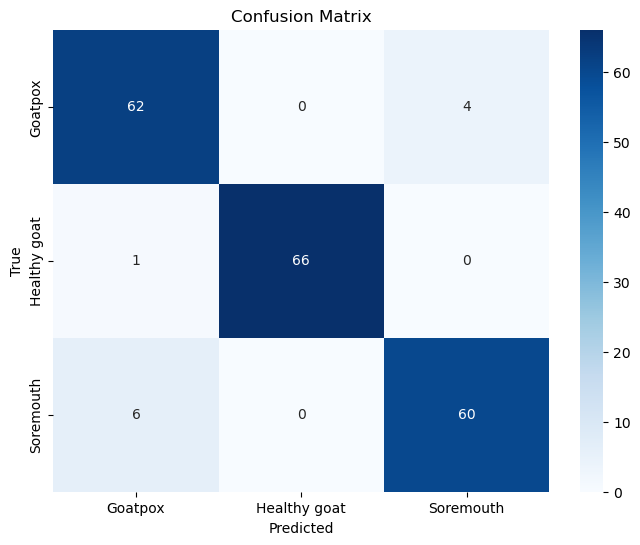

              precision    recall  f1-score   support

     Goatpox       0.90      0.94      0.92        66
Healthy goat       1.00      0.99      0.99        67
   Soremouth       0.94      0.91      0.92        66

    accuracy                           0.94       199
   macro avg       0.95      0.94      0.94       199
weighted avg       0.95      0.94      0.94       199



In [7]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [8]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T

print(metrics_df)

              TP  FP  FN   TN
Goatpox       62   7   4  126
Healthy goat  66   0   1  132
Soremouth     60   4   6  129


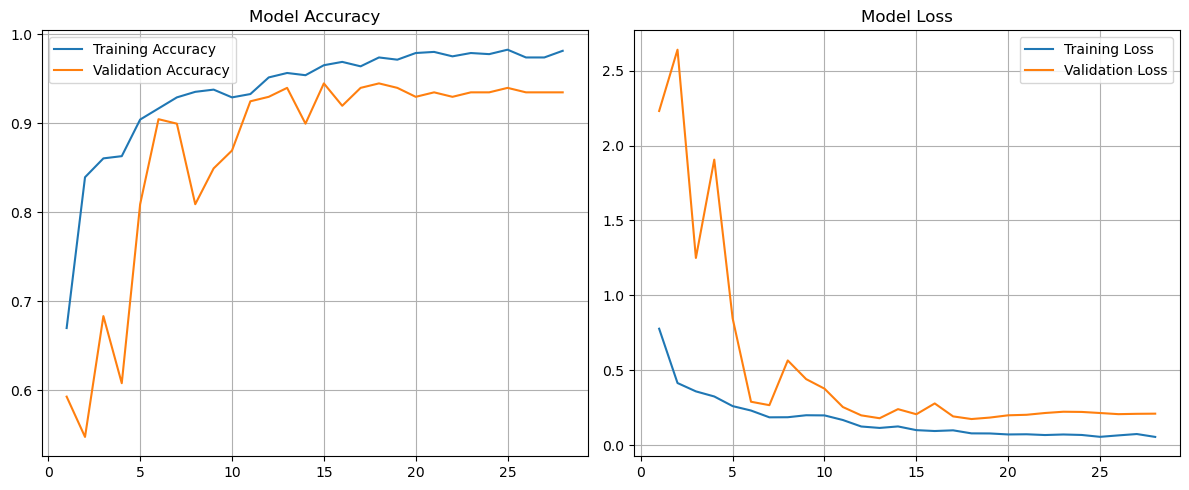

In [9]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
model.save('AImodel_VGG16_Goat.keras')

In [11]:
model.save('AImodel_VGG16_Goat.h5')

ResNet50

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [13]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Goat Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 802 images belonging to 3 classes.
Found 200 images belonging to 3 classes.


In [14]:
class_weights = None

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-15]:
    layer.trainable = False

for layer in base_model.layers[-15:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [16]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 739ms/step - accuracy: 0.6197 - loss: 0.9764 - val_accuracy: 0.5250 - val_loss: 0.9154 - learning_rate: 1.0000e-04
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 732ms/step - accuracy: 0.7618 - loss: 0.6019 - val_accuracy: 0.6450 - val_loss: 0.9433 - learning_rate: 1.0000e-04
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 729ms/step - accuracy: 0.8329 - loss: 0.4282 - val_accuracy: 0.6800 - val_loss: 0.8751 - learning_rate: 1.0000e-04
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 730ms/step - accuracy: 0.8653 - loss: 0.3541 - val_accuracy: 0.6850 - val_loss: 1.2298 - learning_rate: 1.0000e-04
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 722ms/step - accuracy: 0.8691 - loss: 0.3072 - val_accuracy: 0.6900 - val_loss: 1.3137 - learning_rate: 1.0000e-04
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 727ms/step - accuracy: 0.8840 - loss: 0.2916 - val_accuracy: 0.6850 - val_loss: 1.4530 - learning_rate: 1.0000e-04
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 730ms/step - acc

In [17]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 488ms/step - accuracy: 0.6800 - loss: 0.8751
Validation Accuracy: 0.6800000071525574


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 556ms/step


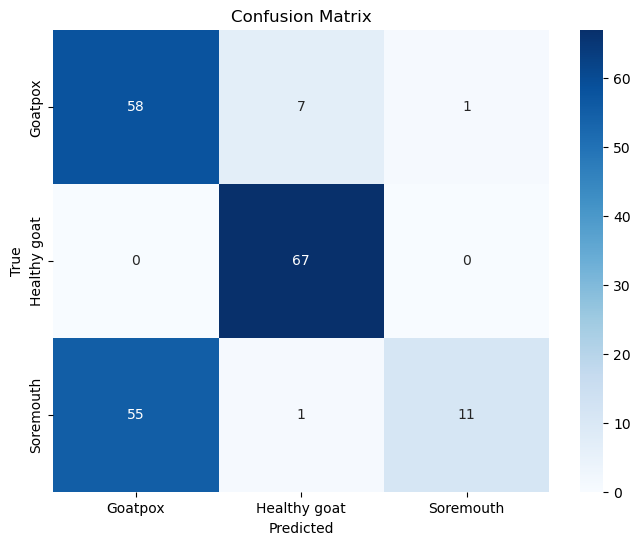

              precision    recall  f1-score   support

     Goatpox       0.51      0.88      0.65        66
Healthy goat       0.89      1.00      0.94        67
   Soremouth       0.92      0.16      0.28        67

    accuracy                           0.68       200
   macro avg       0.77      0.68      0.62       200
weighted avg       0.78      0.68      0.62       200



In [18]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [20]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

              TP  FP  FN   TN
Goatpox       45   3  22  130
Healthy goat  64  12   3  121
Soremouth     58  18   8  116


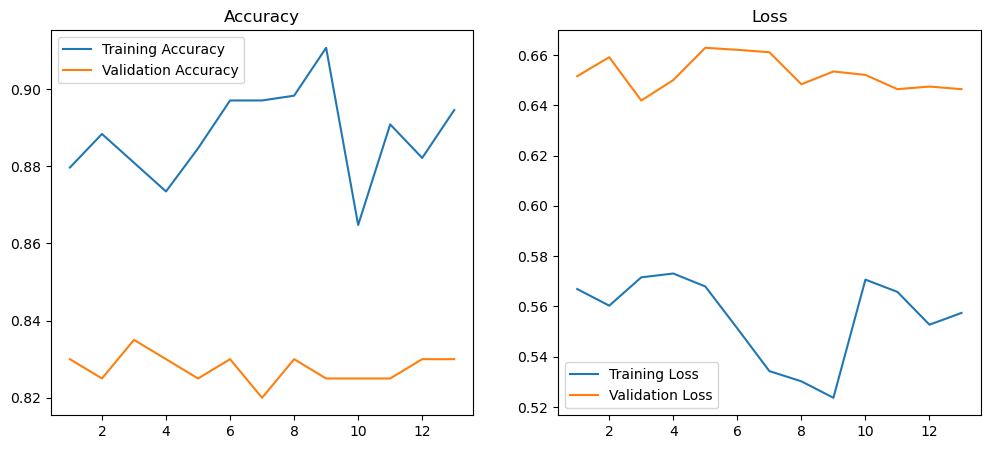

In [21]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
model.save('AImodel_ResNet50_Goat.keras')

In [ ]:
model.save('AImodel_ResNet50_Goat.h5')

In [ ]:
DenseNet121

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

In [24]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Goat Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 806 images belonging to 3 classes.
Found 200 images belonging to 3 classes.


In [25]:
classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.9950617283950617), 1: np.float64(1.0024875621890548), 2: np.float64(1.0024875621890548)}


In [26]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Aggressive unfreezing (simulate fine-tuning in one go)
for layer in base_model.layers[:-35]:
    layer.trainable = False

for layer in base_model.layers[-35:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.000025),   # slightly tuned
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [28]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 49s 741ms/step - accuracy: 0.3933 - loss: 1.3395 - val_accuracy: 0.4650 - val_loss: 1.0484 - learning_rate: 2.5000e-05
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 645ms/step - accuracy: 0.4665 - loss: 1.1418 - val_accuracy: 0.6300 - val_loss: 0.9253 - learning_rate: 2.5000e-05
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 35s 689ms/step - accuracy: 0.5583 - loss: 0.9954 - val_accuracy: 0.6800 - val_loss: 0.8460 - learning_rate: 2.5000e-05
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 665ms/step - accuracy: 0.6203 - loss: 0.9300 - val_accuracy: 0.7250 - val_loss: 0.7853 - learning_rate: 2.5000e-05
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 647ms/step - accuracy: 0.6476 - loss: 0.8653 - val_accuracy: 0.7550 - val_loss: 0.7396 - learning_rate: 2.5000e-05
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 647ms/step - accuracy: 0.7122 - loss: 0.7884 - val_accuracy: 0.7650 - val_loss: 0.6969 - learning_rate: 2.5000e-05
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 653ms/step - acc

In [29]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 465ms/step - accuracy: 0.8650 - loss: 0.5552
Validation Accuracy: 0.8650000095367432


13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 621ms/step


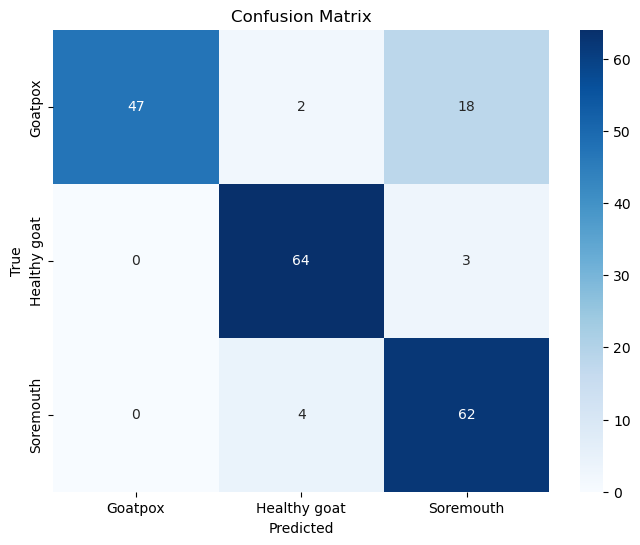

              precision    recall  f1-score   support

     Goatpox       1.00      0.70      0.82        67
Healthy goat       0.91      0.96      0.93        67
   Soremouth       0.75      0.94      0.83        66

    accuracy                           0.86       200
   macro avg       0.89      0.87      0.86       200
weighted avg       0.89      0.86      0.86       200



In [30]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [31]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

              TP  FP  FN   TN
Goatpox       47   0  20  133
Healthy goat  64   6   3  127
Soremouth     62  21   4  113


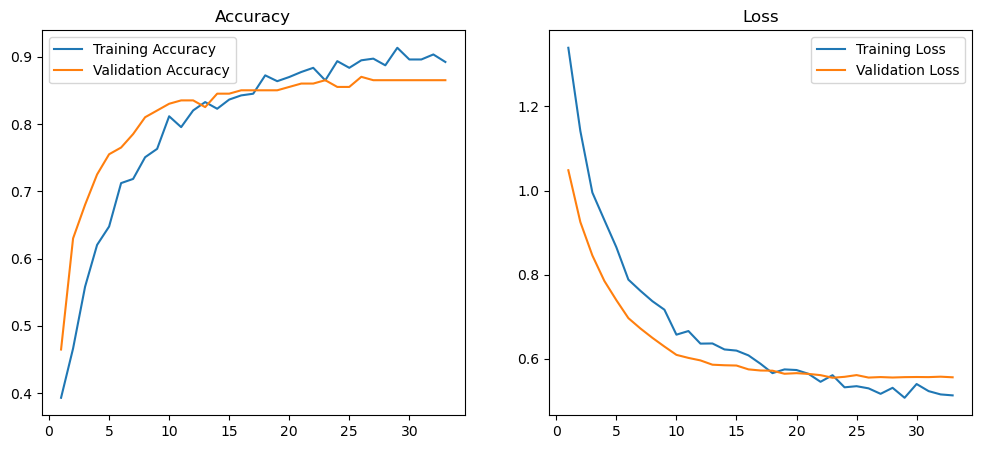

In [32]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [33]:
model.save('AImodel_DenseNet121_Goat.keras')

In [ ]:
MobileNetV2

In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

In [35]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Goat Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 806 images belonging to 3 classes.
Found 200 images belonging to 3 classes.


In [36]:
classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.9950617283950617), 1: np.float64(1.0024875621890548), 2: np.float64(1.0024875621890548)}


In [37]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Unfreeze more layers (MobileNet is lightweight)
for layer in base_model.layers[:-60]:
    layer.trainable = False

for layer in base_model.layers[-60:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.00004),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [38]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [39]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 293ms/step - accuracy: 0.4057 - loss: 1.4474 - val_accuracy: 0.4600 - val_loss: 1.1123 - learning_rate: 4.0000e-05
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 271ms/step - accuracy: 0.5596 - loss: 1.1445 - val_accuracy: 0.5300 - val_loss: 1.1062 - learning_rate: 4.0000e-05
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 284ms/step - accuracy: 0.6328 - loss: 1.0009 - val_accuracy: 0.5600 - val_loss: 1.1218 - learning_rate: 4.0000e-05
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 274ms/step - accuracy: 0.7022 - loss: 0.8896 - val_accuracy: 0.6400 - val_loss: 0.9897 - learning_rate: 4.0000e-05
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 269ms/step - accuracy: 0.7333 - loss: 0.8179 - val_accuracy: 0.6700 - val_loss: 1.0381 - learning_rate: 4.0000e-05
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 262ms/step - accuracy: 0.7866 - loss: 0.7365 - val_accuracy: 0.6900 - val_loss: 1.0300 - learning_rate: 4.0000e-05
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 260ms/step - acc

In [40]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.8150 - loss: 0.7225
Validation Accuracy: 0.8149999976158142


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step


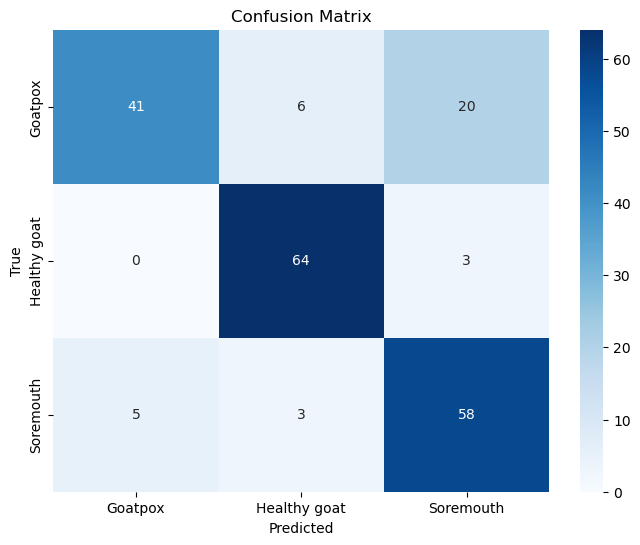

              precision    recall  f1-score   support

     Goatpox       0.89      0.61      0.73        67
Healthy goat       0.88      0.96      0.91        67
   Soremouth       0.72      0.88      0.79        66

    accuracy                           0.81       200
   macro avg       0.83      0.82      0.81       200
weighted avg       0.83      0.81      0.81       200



In [41]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [42]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

              TP  FP  FN   TN
Goatpox       41   5  26  128
Healthy goat  64   9   3  124
Soremouth     58  23   8  111


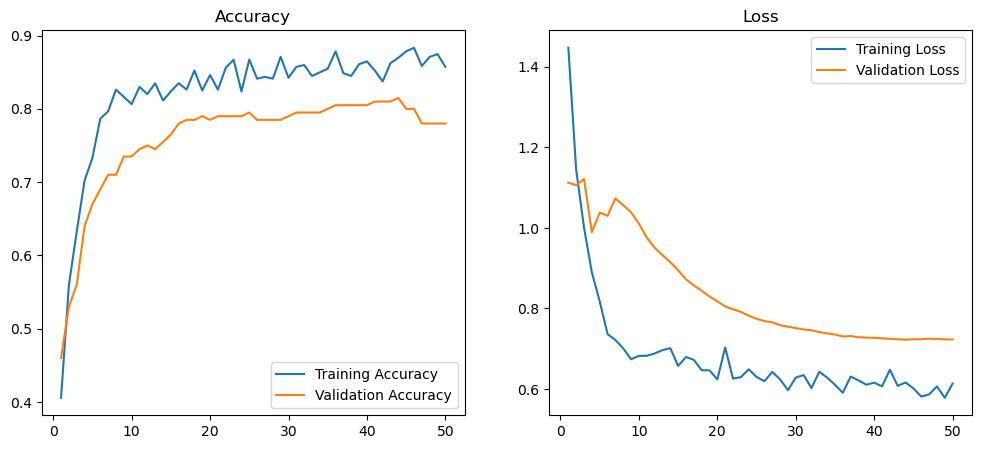

In [43]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [44]:
model.save('AImodel_MobileNetV2_Goat.keras')

In [ ]:
Vision Transformer (ViT)

In [1]:
!pip install vit-keras
!pip install tensorflow-addons

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from vit_keras import vit
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [3]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Goat Dataset'


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 803 images belonging to 3 classes.
Found 199 images belonging to 3 classes.


In [4]:
classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0024968789013733), 1: np.float64(0.9987562189054726), 2: np.float64(0.9987562189054726)}


In [5]:
vit_model = vit.vit_b16(
    image_size=224,
    pretrained=True,
    include_top=False,
    pretrained_top=False
)

# Freeze most layers, fine-tune last 15
for layer in vit_model.layers[:-15]:
    layer.trainable = False

for layer in vit_model.layers[-15:]:
    layer.trainable = True

x = vit_model.output
x = Flatten()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=vit_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.00003),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

/opt/anaconda3/envs/LiveStock-HealthMangmentSystem/lib/python3.11/site-packages/vit_keras/utils.py:85: UserWarning: Resizing position embeddings from 24, 24 to 14, 14
  warnings.warn(


In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [8]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 470s 9s/step - accuracy: 0.4396 - loss: 1.4375 - val_accuracy: 0.6633 - val_loss: 0.8045 - learning_rate: 3.0000e-05
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 455s 9s/step - accuracy: 0.6625 - loss: 0.9524 - val_accuracy: 0.7588 - val_loss: 0.6661 - learning_rate: 3.0000e-05
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 443s 9s/step - accuracy: 0.7621 - loss: 0.7896 - val_accuracy: 0.7990 - val_loss: 0.5840 - learning_rate: 3.0000e-05
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 451s 9s/step - accuracy: 0.7933 - loss: 0.7065 - val_accuracy: 0.8291 - val_loss: 0.5353 - learning_rate: 3.0000e-05
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 454s 9s/step - accuracy: 0.8506 - loss: 0.6375 - val_accuracy: 0.8894 - val_loss: 0.4895 - learning_rate: 3.0000e-05
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 450s 9s/step - accuracy: 0.8518 - loss: 0.6467 - val_accuracy: 0.9095 - val_loss: 0.4907 - learning_rate: 3.0000e-05
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 450s 9s/step - accuracy: 0.8829 

In [9]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.9397 - loss: 0.4586
Validation Accuracy: 0.9396985173225403


13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step


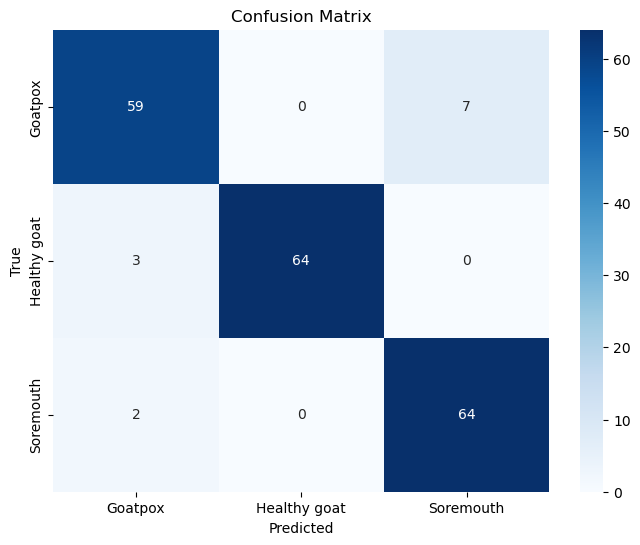

              precision    recall  f1-score   support

     Goatpox       0.92      0.89      0.91        66
Healthy goat       1.00      0.96      0.98        67
   Soremouth       0.90      0.97      0.93        66

    accuracy                           0.94       199
   macro avg       0.94      0.94      0.94       199
weighted avg       0.94      0.94      0.94       199



In [10]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [11]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

              TP  FP  FN   TN
Goatpox       59   5   7  128
Healthy goat  64   0   3  132
Soremouth     64   7   2  126


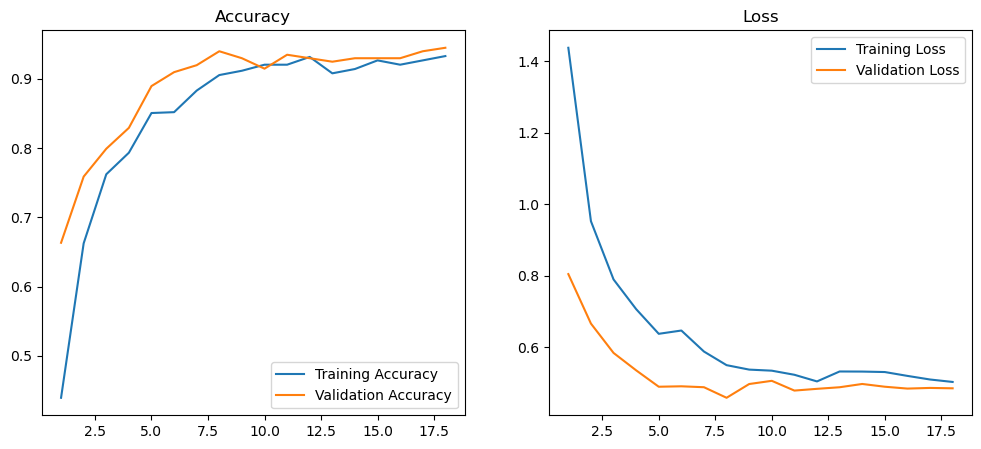

In [12]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [13]:
model.save('AImodel_ViT_Goat.keras')

In [14]:
model.save('AImodel_ViT_Goat.h5')